# Loading data

In [15]:
import pandas as pd
import numpy as np
df = pd.read_csv("insurance_data.csv")
df.head()

,age,affordibility,bought_insurance
0,22,1,0
1,25,0,0
2,47,1,1
3,52,0,0
4,46,1,1


In [16]:
df['age'] = df['age']/100

In [17]:
from sklearn.model_selection import train_test_split
X = df.drop('bought_insurance', axis=1)
y = df['bought_insurance']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=25)

# Training the network

In [ ]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(1, input_shape=(2,), activation='sigmoid', kernel_initializer='ones', bias_initializer='zeros')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=3500)

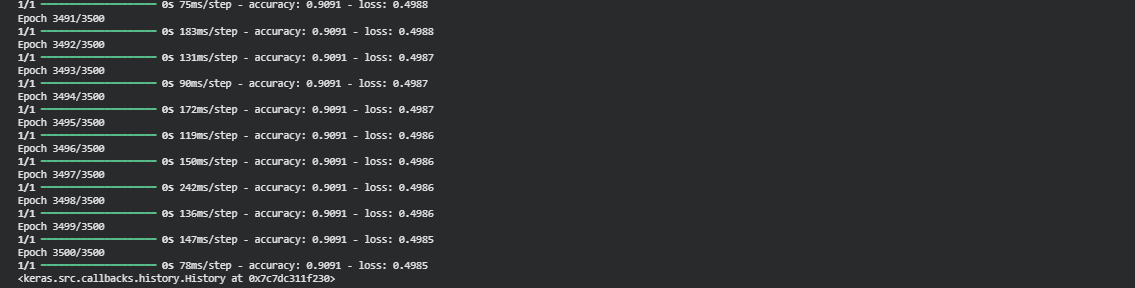

In [18]:
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.8333 - loss: 0.4239


[0.42385706305503845, 0.8333333134651184]

In [19]:
model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


array([[0.684597  ],
       [0.43187433],
       [0.2283641 ],
       [0.52188116],
       [0.7000082 ],
       [0.78270215]], dtype=float32)

In [20]:
y_test

,bought_insurance
2,1
10,0
21,0
11,0
14,1
9,1


In [21]:
coef, intercept = model.get_weights()

In [22]:
coef

array([[3.6178865],
       [1.2327944]], dtype=float32)

In [23]:
intercept

array([-2.158222], dtype=float32)

# Defining our own prediction function

In [24]:
def sigmoid(x):
  import math
  return 1/(1+math.exp(-x))

In [25]:
def prediction_function(age, affordability):
  weighted_sum = coef[0]*age + coef[1]*affordability + intercept
  return sigmoid(weighted_sum)

In [27]:
prediction_function(0.45, 1)

/tmp/ipython-input-44274363.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1/(1+math.exp(-x))


0.6687686743002447

# Defining our own gradient descent function

In [28]:
def sigmoid_numpy(X):
   return 1/(1+np.exp(-X))

In [29]:
def log_loss(y_true, y_predicted):
    epsilon = 1e-15
    y_predicted_new = [max(i,epsilon) for i in y_predicted]
    y_predicted_new = [min(i,1-epsilon) for i in y_predicted_new]
    y_predicted_new = np.array(y_predicted_new)
    return -np.mean(y_true*np.log(y_predicted_new)+(1-y_true)*np.log(1-y_predicted_new))

In [35]:
def gradient_descent(age, affordability, y_true, epochs, loss_threshold):
  w1 = w2 = 1
  bias = 0
  rate = 0.5
  n = len(age)

  for i in range(epochs):
    weighted_sum = w1*age + w2*affordability + bias
    y_predicted = sigmoid_numpy(weighted_sum)
    loss = log_loss(y_true, y_predicted)

    w1d = (1/n)*np.dot(np.transpose(age), (y_predicted-y_true))
    w2d = (1/n)*np.dot(np.transpose(affordability), (y_predicted-y_true))
    bias_d = np.mean(y_predicted-y_true)

    w1 = w1 - rate*w1d
    w2 = w2 - rate*w2d
    bias = bias - rate*bias_d

    print (f'Epoch:{i}, w1:{w1}, w2:{w2}, bias:{bias}, loss:{loss}')

    if loss <= loss_threshold:
      break

  return w1, w2, bias

In [ ]:
gradient_descent(X_train['age'], X_train['affordibility'], y_train, 500, 0.4985)

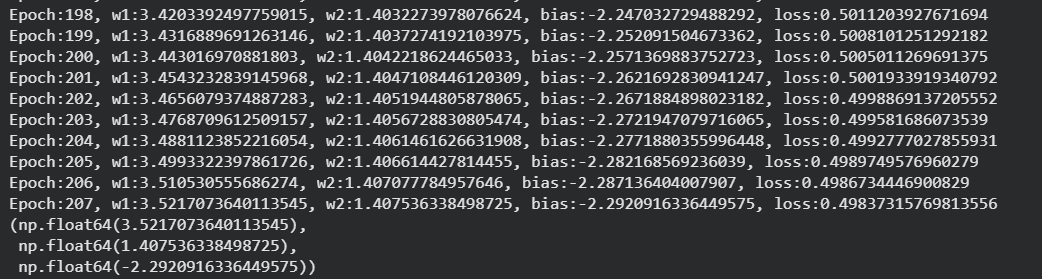

In [37]:
coef, intercept

(array([[3.6178865],
        [1.2327944]], dtype=float32),
 array([-2.158222], dtype=float32))

# Defining our own custom neural network class

In [48]:
class Neural_Network:
  def __init__(self):
    self.w1 = 1
    self.w2 = 1
    self.bias = 0

  def fit(self, X, Y, epochs, loss_threshold):
    self.w1, self.w2, self.bias = self.gradient_descent(X['age'], X['affordibility'], Y, epochs, loss_threshold)
    print (f'Final weights and bias:- w1:{self.w1}, w2:{self.w2}, bias:{self.bias}')

  def predict(self, X_test):
    weighted_sum = self.w1*X_test['age'] + self.w2*X_test['affordibility'] + self.bias
    return sigmoid_numpy(weighted_sum)

  def gradient_descent(self, age, affordability, y_true, epochs, loss_threshold):
    w1 = w2 = 1
    bias = 0
    rate = 0.5
    n = len(age)

    for i in range(epochs):
      weighted_sum = w1*age + w2*affordability + bias
      y_predicted = sigmoid_numpy(weighted_sum)
      loss = log_loss(y_true, y_predicted)

      w1d = (1/n)*np.dot(np.transpose(age), (y_predicted-y_true))
      w2d = (1/n)*np.dot(np.transpose(affordability), (y_predicted-y_true))
      bias_d = np.mean(y_predicted-y_true)

      w1 = w1 - rate*w1d
      w2 = w2 - rate*w2d
      bias = bias - rate*bias_d

      if loss <= loss_threshold:
        print (f'Epoch:{i}, w1:{w1}, w2:{w2}, bias:{bias}, loss:{loss}')
        break
    return w1, w2, bias


In [49]:
nn = Neural_Network()
nn.fit(X_train, y_train, epochs=500, loss_threshold=0.4985)

Epoch:207, w1:3.5217073640113545, w2:1.407536338498725, bias:-2.2920916336449575, loss:0.49837315769813556
Final weights and bias:- w1:3.5217073640113545, w2:1.407536338498725, bias:-2.2920916336449575


In [50]:
nn.predict(X_test)

,0
2,0.683661
10,0.437664
21,0.201580
11,0.525359
14,0.698693
9,0.779660
